# Eksperimen Pengaruh Regularisasi

Notebook ini menjalankan 3 eksperimen (tanpa regularisasi, L1, L2) dan aakan membandingkan:
1. Hasil akhir prediksinya
2. Grafik training loss dan validation loss tiap epoch setelah pelatihan
3. Distribusi bobot dan gradien bobot dari setiap layer pada model

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
import ffnn
# importlib.reload(ffnn) 

%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Data Loading & Preprocessing

In [63]:
# Load dataset
df = pd.read_csv("../data/dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['placement_status'].value_counts()}")
df.head()

Dataset shape: (10000, 12)
Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [64]:
# Encode categorical features
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'placement_status' in categorical_cols:
    categorical_cols.remove('placement_status')

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target
target_le = LabelEncoder()
df['placement_status'] = target_le.fit_transform(df['placement_status'])

# Separate features and target
X = df.drop('placement_status', axis=1).values
y = df['placement_status'].values

num_classes = len(np.unique(y))
num_features = X.shape[1]
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {target_le.classes_}")

# Split into train, validation, test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Number of features: 11
Number of classes: 2
Classes: ['Not Placed' 'Placed']

Train: 7000 samples
Val:   1500 samples
Test:  1500 samples


## 2. Definisi Model

Menggunakan arsitektur yang sama untuk ketiga eksperimen tersebut agar hasilnya lebih fair.

In [65]:
def create_model(num_features, num_classes, seed=42):
    np.random.seed(seed)
    model = ffnn.Model(
        layers=[
            ffnn.Linear(num_features, 64),
            ffnn.Relu(),
            ffnn.Linear(64, 32),
            ffnn.Relu(),
            ffnn.Linear(32, num_classes),
            ffnn.Softmax(),
        ],
        loss=ffnn.CrossEntropyLoss(),
    )
    return model

EPOCHS = 50
LR = 0.01
BATCH_SIZE = 32
LAMBDA = 0.001
SEED = 42

print("Arsitektur: Linear(in, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, out) -> Softmax")
print(f"Epochs: {EPOCHS}, LR: {LR}, Batch Size: {BATCH_SIZE}, Lambda: {LAMBDA}")

Arsitektur: Linear(in, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, out) -> Softmax
Epochs: 50, LR: 0.01, Batch Size: 32, Lambda: 0.001


## 3. Menjalankan Eksperimen

### 3.1 Tanpa Regularisasi

In [66]:
model_none = create_model(num_features, num_classes, seed=SEED)
history_none = model_none.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty=None, lambda_=0.0,
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1, Train Loss: 0.619955, Val Loss: 0.619892


Epoch 2, Train Loss: 0.581233, Val Loss: 0.582548
Epoch 3, Train Loss: 0.555522, Val Loss: 0.557677
Epoch 4, Train Loss: 0.538645, Val Loss: 0.541713
Epoch 5, Train Loss: 0.528140, Val Loss: 0.532573
Epoch 6, Train Loss: 0.521664, Val Loss: 0.527337
Epoch 7, Train Loss: 0.517437, Val Loss: 0.524274
Epoch 8, Train Loss: 0.514489, Val Loss: 0.522383
Epoch 9, Train Loss: 0.512467, Val Loss: 0.521354
Epoch 10, Train Loss: 0.510896, Val Loss: 0.520478
Epoch 11, Train Loss: 0.509650, Val Loss: 0.519915
Epoch 12, Train Loss: 0.508568, Val Loss: 0.519413
Epoch 13, Train Loss: 0.507596, Val Loss: 0.519005
Epoch 14, Train Loss: 0.506650, Val Loss: 0.518506
Epoch 15, Train Loss: 0.505950, Val Loss: 0.518303
Epoch 16, Train Loss: 0.504941, Val Loss: 0.517593
Epoch 17, Train Loss: 0.504165, Val Loss: 0.517270
Epoch 18, Train Loss: 0.503485, Val Loss: 0.516951
Epoch 19, Train Loss: 0.502742, Val Loss: 0.516549
Epoch 20, Train Loss: 0.502078, Val Loss: 0.516115
Epoch 21, Train Loss: 0.501454, Val Lo

### 3.2 Regularisasi L1

In [67]:
model_l1 = create_model(num_features, num_classes, seed=SEED)
history_l1 = model_l1.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty="l1", lambda_=LAMBDA,
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1, Train Loss: 0.985985, Val Loss: 0.985933
Epoch 2, Train Loss: 0.942958, Val Loss: 0.944207
Epoch 3, Train Loss: 0.912659, Val Loss: 0.914720
Epoch 4, Train Loss: 0.890297, Val Loss: 0.893167
Epoch 5, Train Loss: 0.873893, Val Loss: 0.877994
Epoch 6, Train Loss: 0.861520, Val Loss: 0.866695
Epoch 7, Train Loss: 0.851278, Val Loss: 0.857397
Epoch 8, Train Loss: 0.842391, Val Loss: 0.849274
Epoch 9, Train Loss: 0.834580, Val Loss: 0.842177
Epoch 10, Train Loss: 0.827276, Val Loss: 0.835430
Epoch 11, Train Loss: 0.820486, Val Loss: 0.829193
Epoch 12, Train Loss: 0.813899, Val Loss: 0.823015
Epoch 13, Train Loss: 0.807651, Val Loss: 0.817013
Epoch 14, Train Loss: 0.801629, Val Loss: 0.811174
Epoch 15, Train Loss: 0.795684, Val Loss: 0.805387
Epoch 16, Train Loss: 0.789883, Val Loss: 0.799669
Epoch 17, Train Loss: 0.784130, Val Loss: 0.794081
Epoch 18, Train Loss: 0.778465, Val Loss: 0.788489
Epoch 19, Train Loss: 0.772934, Val Loss: 0.783046
Epoch 20, Train Loss: 0.767546, Val Loss

### 3.3 Regularisasi L2

In [68]:
model_l2 = create_model(num_features, num_classes, seed=SEED)
history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty="l2", lambda_=LAMBDA,
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1, Train Loss: 0.686107, Val Loss: 0.686059
Epoch 2, Train Loss: 0.647645, Val Loss: 0.648952
Epoch 3, Train Loss: 0.621978, Val Loss: 0.624127
Epoch 4, Train Loss: 0.604790, Val Loss: 0.607826
Epoch 5, Train Loss: 0.593696, Val Loss: 0.598054
Epoch 6, Train Loss: 0.586595, Val Loss: 0.592056
Epoch 7, Train Loss: 0.581667, Val Loss: 0.588214
Epoch 8, Train Loss: 0.578067, Val Loss: 0.585592
Epoch 9, Train Loss: 0.575421, Val Loss: 0.583832
Epoch 10, Train Loss: 0.573214, Val Loss: 0.582283
Epoch 11, Train Loss: 0.571399, Val Loss: 0.581120
Epoch 12, Train Loss: 0.569730, Val Loss: 0.579989
Epoch 13, Train Loss: 0.568252, Val Loss: 0.579013
Epoch 14, Train Loss: 0.566876, Val Loss: 0.578054
Epoch 15, Train Loss: 0.565671, Val Loss: 0.577281
Epoch 16, Train Loss: 0.564347, Val Loss: 0.576221
Epoch 17, Train Loss: 0.563165, Val Loss: 0.575385
Epoch 18, Train Loss: 0.562078, Val Loss: 0.574537
Epoch 19, Train Loss: 0.560993, Val Loss: 0.573680
Epoch 20, Train Loss: 0.559982, Val Loss

## 4. Perbandingan Hasil Prediksi

In [69]:
# Predict on test set
preds_none = model_none.predict(X_test)
preds_l1 = model_l1.predict(X_test)
preds_l2 = model_l2.predict(X_test)

acc_none = accuracy_score(y_test, preds_none)
acc_l1 = accuracy_score(y_test, preds_l1)
acc_l2 = accuracy_score(y_test, preds_l2)

print("ACCURACY COMPARISON")
print(f"{'Model':<25} {'Accuracy':>10}")
print(f"{'Tanpa Regularisasi':<23} {acc_none:>10.4f}")
print(f"{'L1 Regularisasi':<25} {acc_l1:>10.4f}")
print(f"{'L2 Regularisasi':<25} {acc_l2:>10.4f}")
print("=" * 60)

ACCURACY COMPARISON
Model                       Accuracy
Tanpa Regularisasi          0.7620
L1 Regularisasi               0.7600
L2 Regularisasi               0.7640


In [70]:
for name, preds in [("Tanpa Regularisasi", preds_none), ("L1", preds_l1), ("L2", preds_l2)]:
    print(f"Classification Report - {name}")
    print(classification_report(y_test, preds, target_names=target_le.classes_))

Classification Report - Tanpa Regularisasi
              precision    recall  f1-score   support

  Not Placed       0.72      0.63      0.67       577
      Placed       0.79      0.84      0.81       923

    accuracy                           0.76      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.76      0.76      0.76      1500

Classification Report - L1
              precision    recall  f1-score   support

  Not Placed       0.72      0.61      0.66       577
      Placed       0.78      0.85      0.81       923

    accuracy                           0.76      1500
   macro avg       0.75      0.73      0.74      1500
weighted avg       0.76      0.76      0.76      1500

Classification Report - L2
              precision    recall  f1-score   support

  Not Placed       0.72      0.63      0.67       577
      Placed       0.79      0.85      0.82       923

    accuracy                           0.76      1500
   macro avg       0.75      0.

In [71]:
print("\nSample Predictions (first 20 test samples):")
print(f"{'Actual':<10} {'None':<10} {'L1':<10} {'L2':<10}")
print("-" * 40)
for i in range(min(20, len(y_test))):
    print(f"{y_test[i]:<10} {preds_none[i]:<10} {preds_l1[i]:<10} {preds_l2[i]:<10}")


Sample Predictions (first 20 test samples):
Actual     None       L1         L2        
----------------------------------------
1          1          1          1         
1          1          1          1         
1          1          1          1         
1          1          1          1         
1          0          1          0         
1          1          1          1         
1          1          1          1         
1          1          1          1         
1          1          1          1         
0          1          1          1         
1          1          1          1         
0          0          0          0         
1          1          1          1         
1          1          1          1         
1          1          1          1         
0          1          1          1         
1          0          0          0         
1          0          0          0         
1          1          1          1         
0          0          0          0

## 5. Grafik Training Loss dan Validation Loss

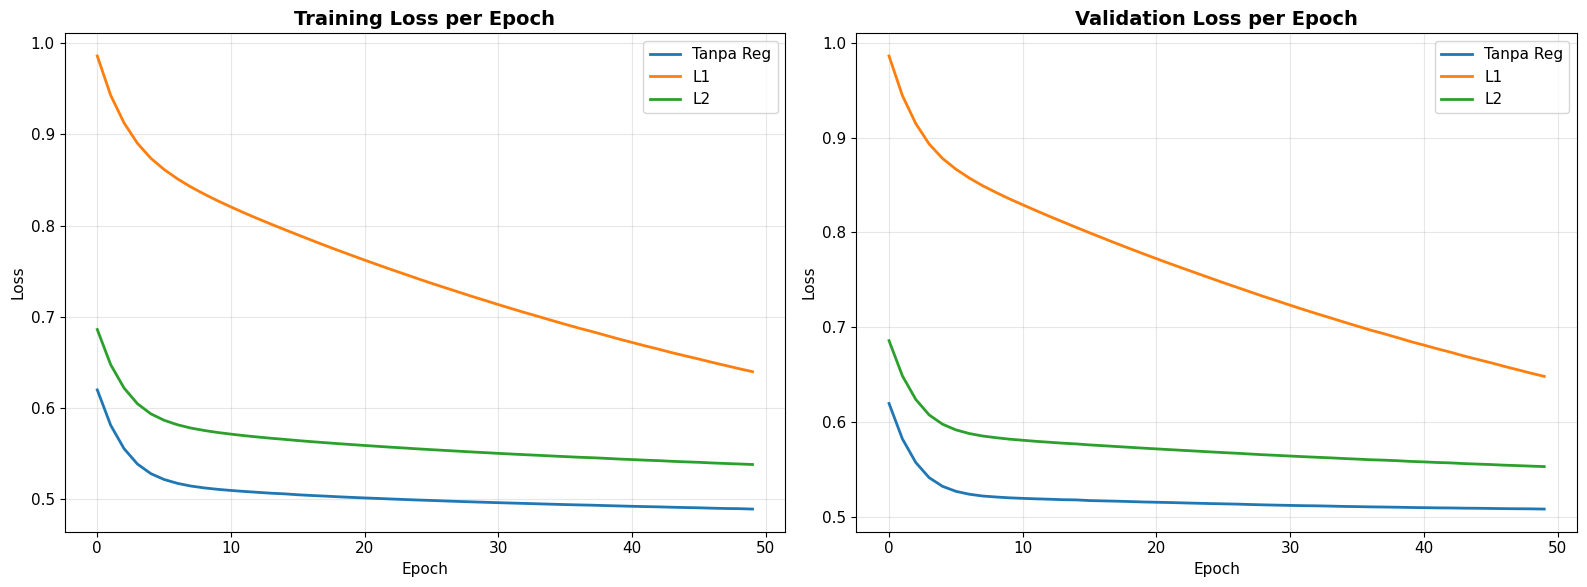

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Loss
ax = axes[0]
ax.plot(history_none["train_loss"], label="Tanpa Reg", linewidth=2)
ax.plot(history_l1["train_loss"], label="L1", linewidth=2)
ax.plot(history_l2["train_loss"], label="L2", linewidth=2)
ax.set_title("Training Loss per Epoch", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[1]
ax.plot(history_none["val_loss"], label="Tanpa Reg", linewidth=2)
ax.plot(history_l1["val_loss"], label="L1", linewidth=2)
ax.plot(history_l2["val_loss"], label="L2", linewidth=2)
ax.set_title("Validation Loss per Epoch", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

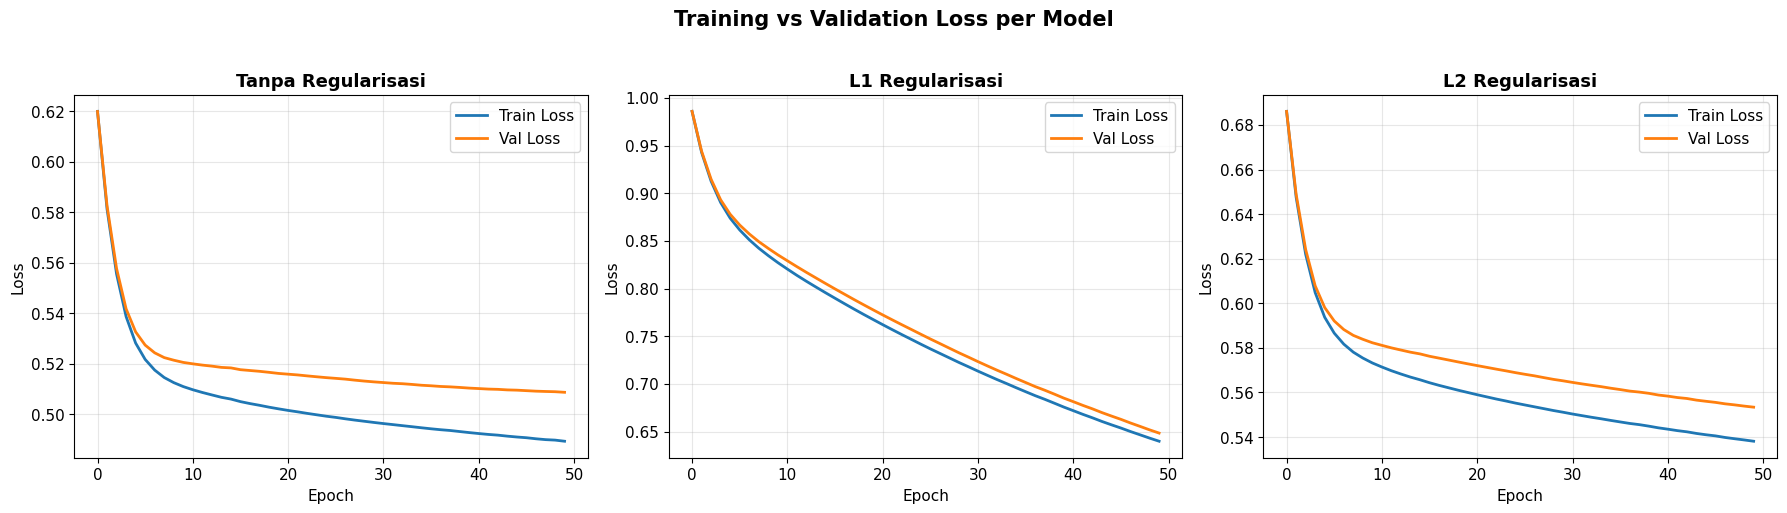

In [73]:
# Individual plots per model (train vs val overlay)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, history) in zip(axes, [
    ("Tanpa Regularisasi", history_none),
    ("L1 Regularisasi", history_l1),
    ("L2 Regularisasi", history_l2)
]):
    ax.plot(history["train_loss"], label="Train Loss", linewidth=2, color='tab:blue')
    ax.plot(history["val_loss"], label="Val Loss", linewidth=2, color='tab:orange')
    ax.set_title(f"{name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Training vs Validation Loss per Model", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("loss_per_model.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribusi Bobot (Weight Distribution)

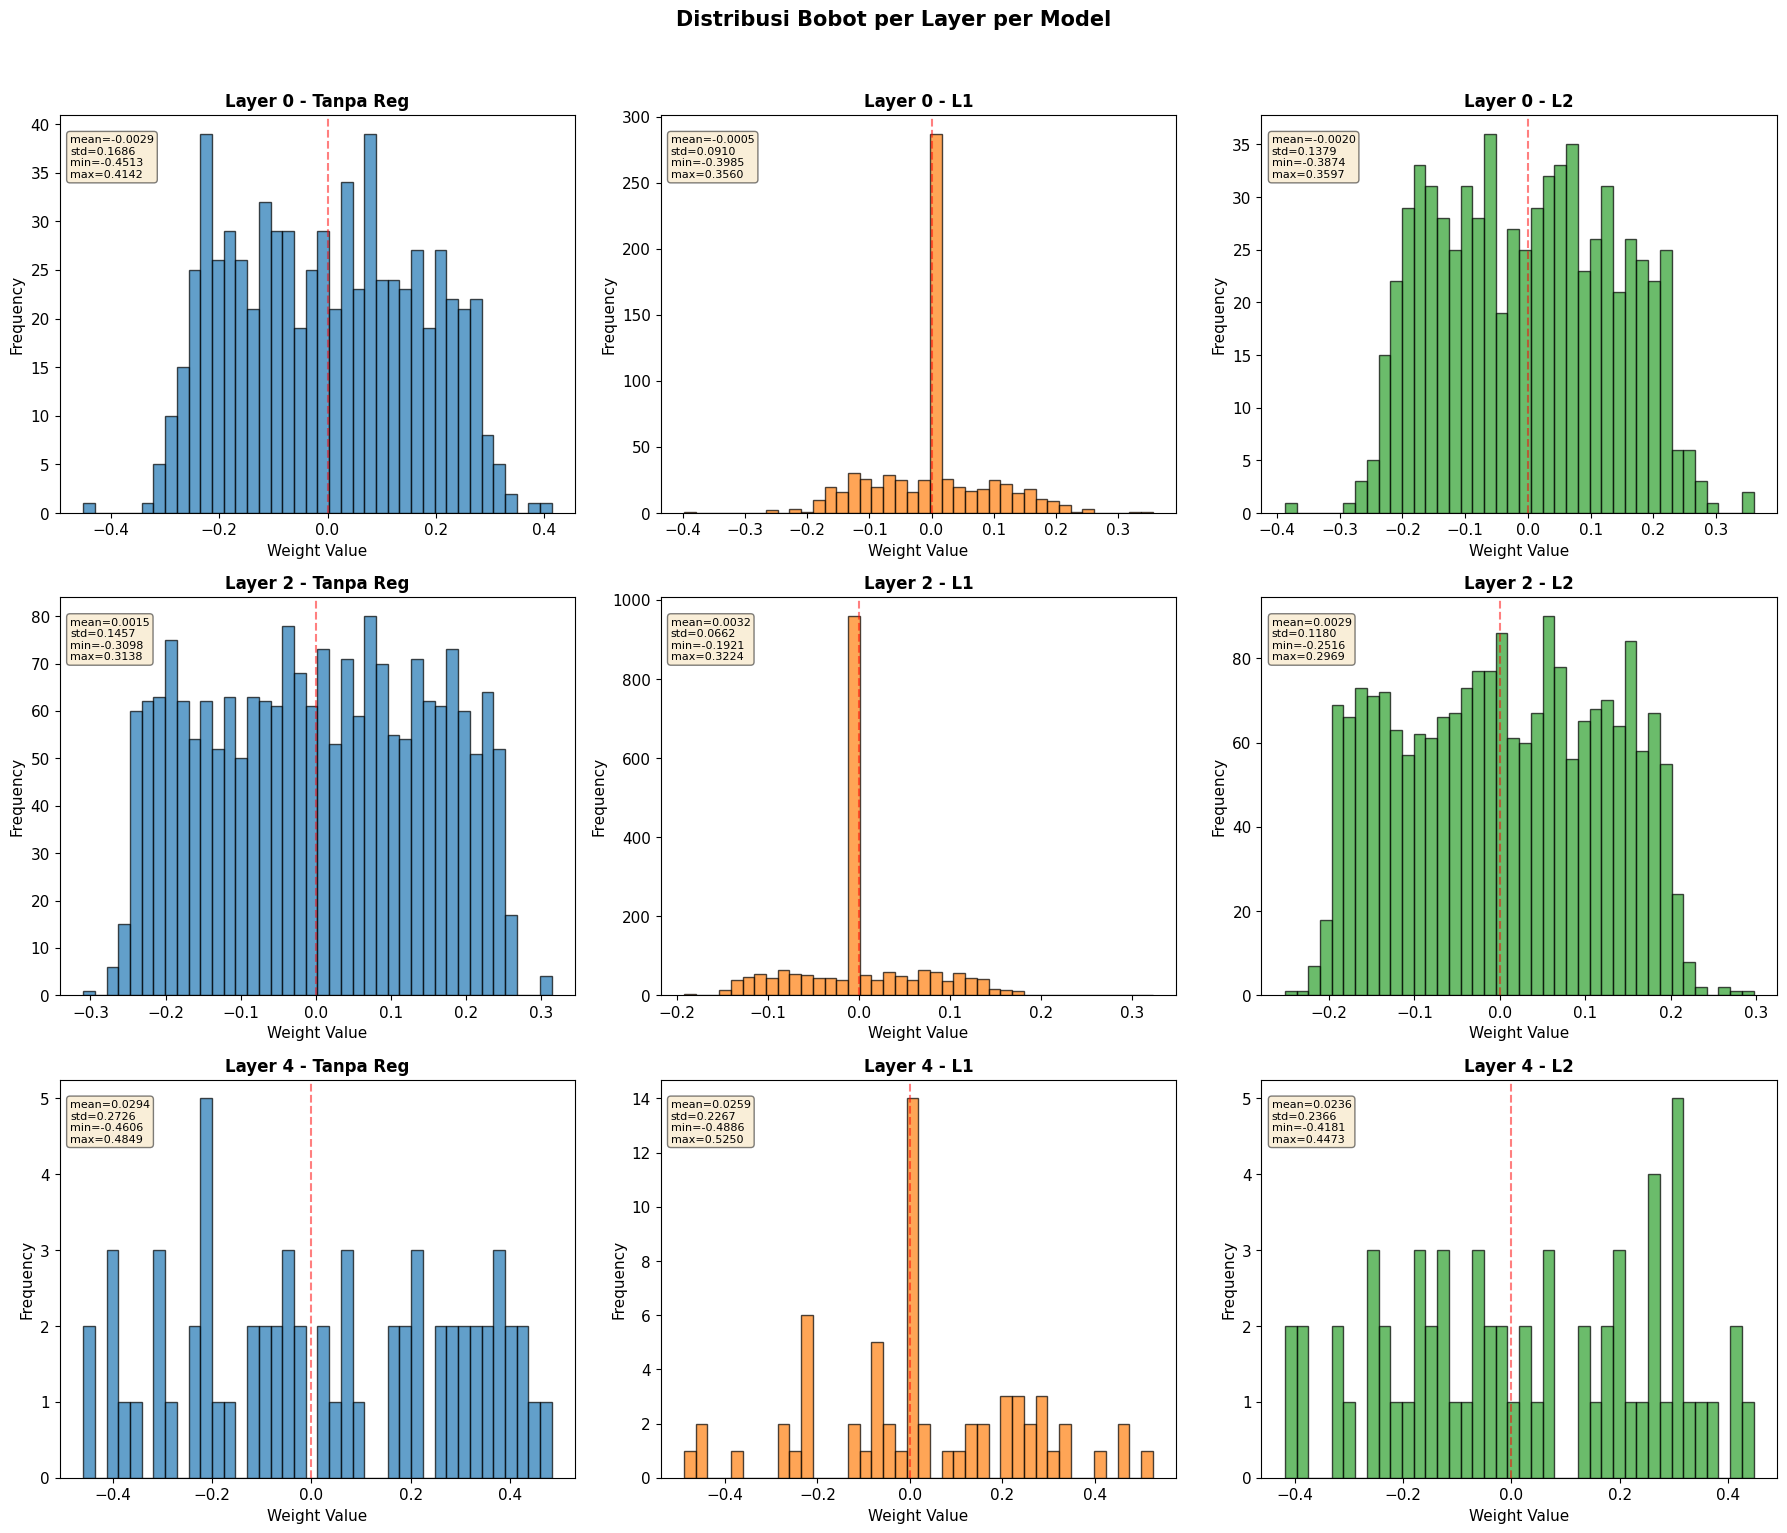

In [74]:
linear_indices = [i for i, l in enumerate(model_none.layers) if isinstance(l, ffnn.Linear)]

models = {
    "Tanpa Reg": model_none,
    "L1": model_l1,
    "L2": model_l2,
}
colors = {"Tanpa Reg": "tab:blue", "L1": "tab:orange", "L2": "tab:green"}

fig, axes = plt.subplots(len(linear_indices), 3, figsize=(18, 5 * len(linear_indices)))

for row, li in enumerate(linear_indices):
    for col, (name, model) in enumerate(models.items()):
        ax = axes[row, col] if len(linear_indices) > 1 else axes[col]
        layer = model.layers[li]
        w = layer.weights.data.flatten()
        ax.hist(w, bins=40, edgecolor='black', alpha=0.7, color=colors[name])
        ax.set_title(f"Layer {li} - {name}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Weight Value")
        ax.set_ylabel("Frequency")
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        ax.text(0.02, 0.95, f"mean={w.mean():.4f}\nstd={w.std():.4f}\nmin={w.min():.4f}\nmax={w.max():.4f}",
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Distribusi Bobot per Layer per Model", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("weight_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Distribusi Gradien Bobot (Gradient Distribution)

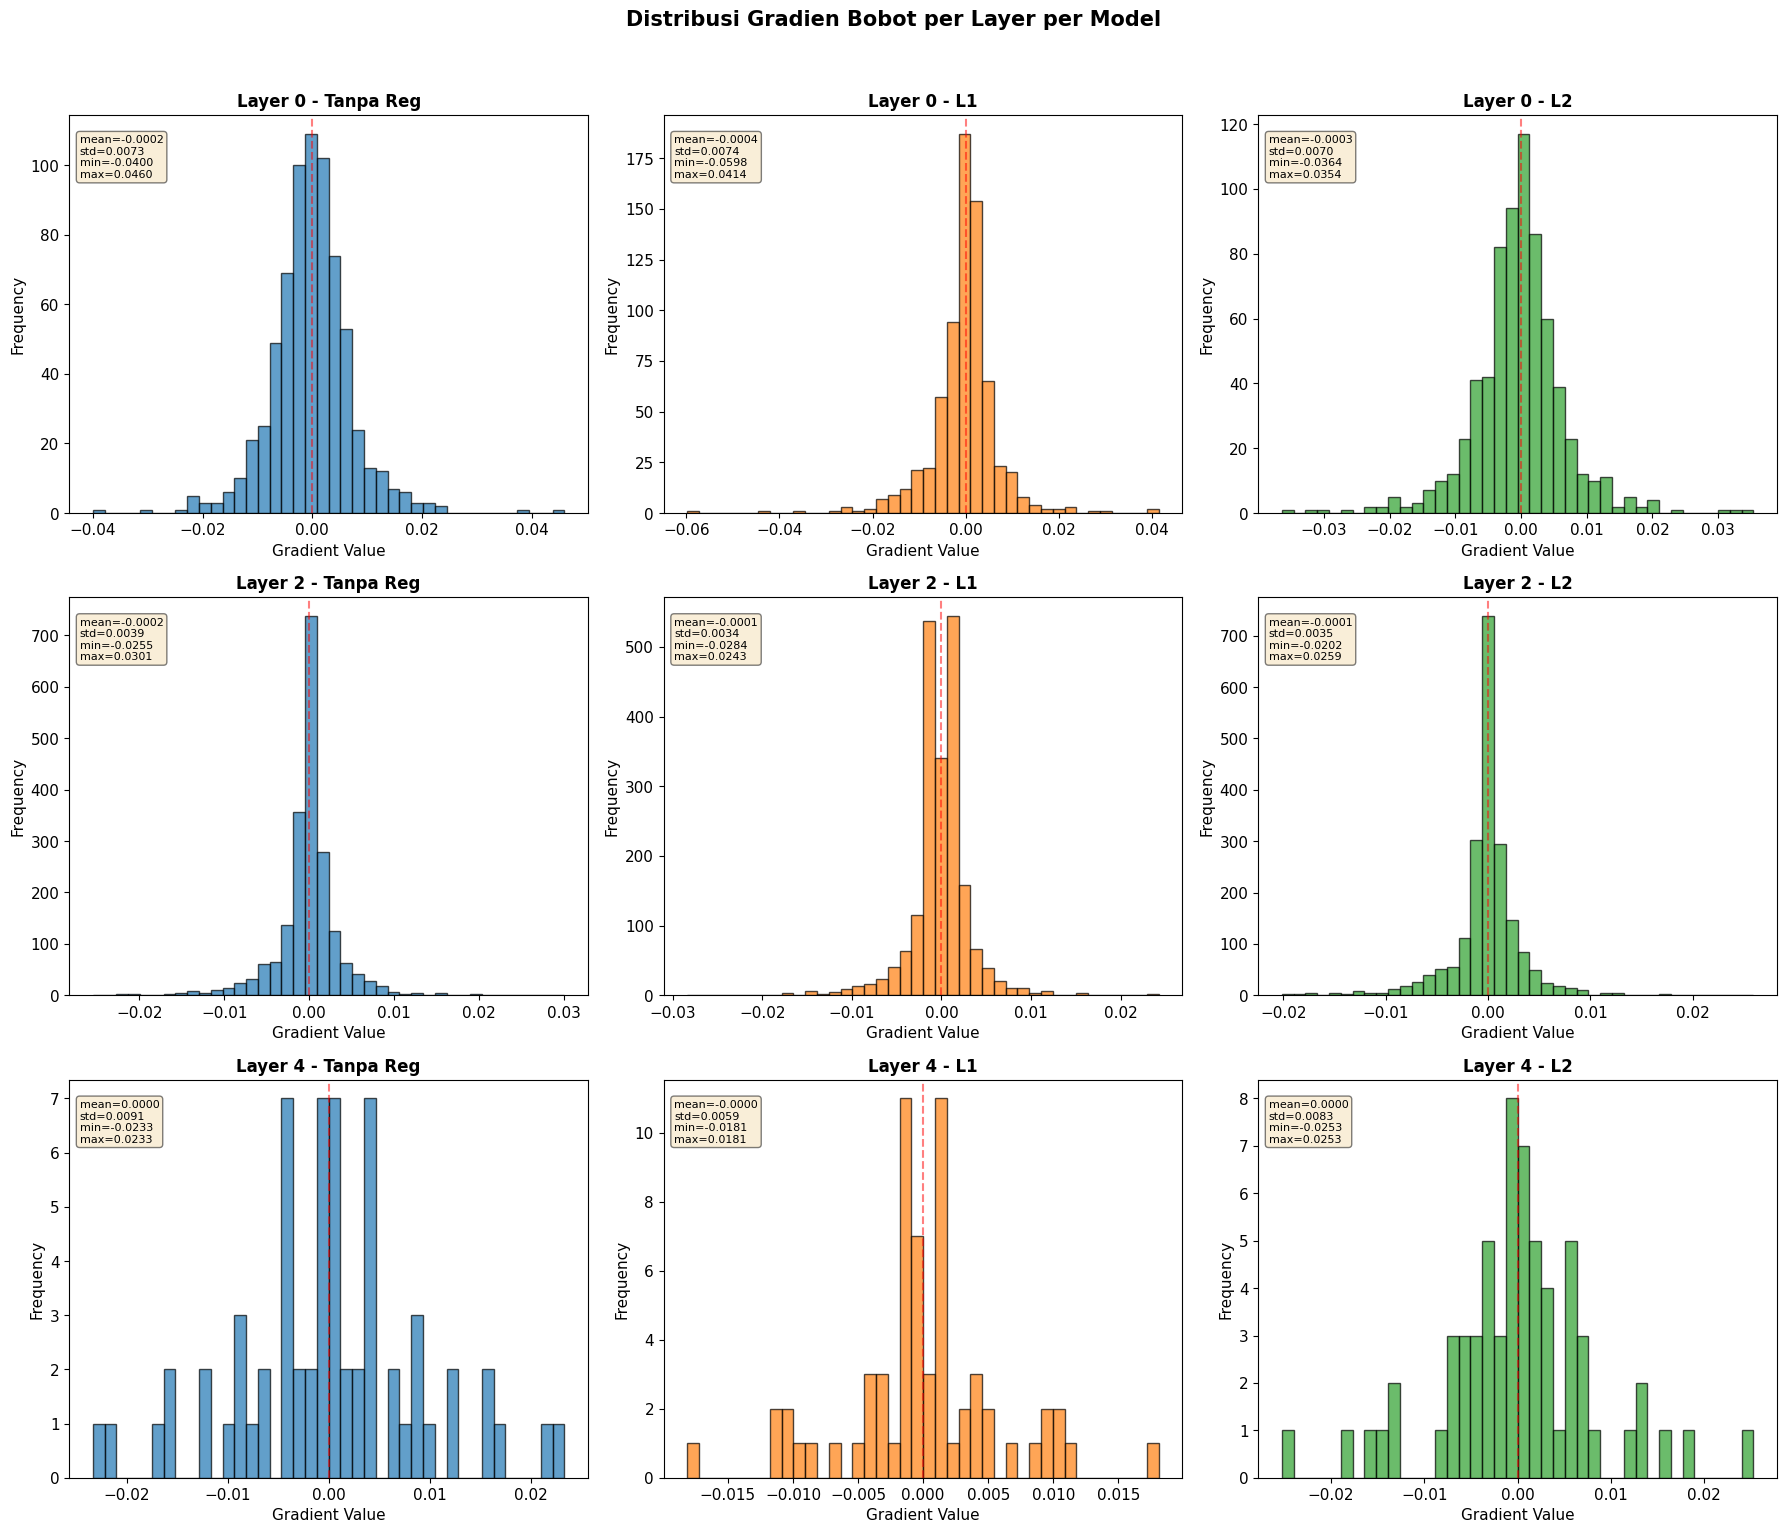

In [75]:
fig, axes = plt.subplots(len(linear_indices), 3, figsize=(18, 5 * len(linear_indices)))

for row, li in enumerate(linear_indices):
    for col, (name, model) in enumerate(models.items()):
        ax = axes[row, col] if len(linear_indices) > 1 else axes[col]
        layer = model.layers[li]
        if hasattr(layer, 'grad'):
            g = layer.grad.flatten()
            ax.hist(g, bins=40, edgecolor='black', alpha=0.7, color=colors[name])
            ax.set_title(f"Layer {li} - {name}", fontsize=12, fontweight='bold')
            ax.set_xlabel("Gradient Value")
            ax.set_ylabel("Frequency")
            ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
            ax.text(0.02, 0.95, f"mean={g.mean():.4f}\nstd={g.std():.4f}\nmin={g.min():.4f}\nmax={g.max():.4f}",
                    transform=ax.transAxes, fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            ax.set_title(f"Layer {li} - {name} (no grad)", fontsize=12)
            ax.text(0.5, 0.5, "No gradient data", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Distribusi Gradien Bobot per Layer per Model", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("gradient_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Ringkasan Hasil

In [76]:
summary_data = {
    "Model": ["Tanpa Regularisasi", "L1 Regularisasi", "L2 Regularisasi"],
    "Test Accuracy": [f"{acc_none:.4f}", f"{acc_l1:.4f}", f"{acc_l2:.4f}"],
    "Final Train Loss": [f"{history_none['train_loss'][-1]:.6f}", f"{history_l1['train_loss'][-1]:.6f}", f"{history_l2['train_loss'][-1]:.6f}"],
    "Final Val Loss": [f"{history_none['val_loss'][-1]:.6f}", f"{history_l1['val_loss'][-1]:.6f}", f"{history_l2['val_loss'][-1]:.6f}"],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

             Model Test Accuracy Final Train Loss Final Val Loss
Tanpa Regularisasi        0.7620         0.489252       0.508635
   L1 Regularisasi        0.7600         0.639870       0.648418
   L2 Regularisasi        0.7640         0.538108       0.553388


In [77]:
print("\nWeight Sparsity Analysis:")
print(f"{'Model':<25} ", end="")
for li in linear_indices:
    print(f"{'Layer '+str(li):>12}", end="")
print()
for name, model in models.items():
    print(f"{name:<25} ", end="")
    for li in linear_indices:
        layer = model.layers[li]
        w = layer.weights.data.flatten()
        sparsity = np.sum(np.abs(w) < 0.01) / len(w) * 100
        print(f"{sparsity:>11.2f}%", end="")
    print()


Weight Sparsity Analysis:
Model                          Layer 0     Layer 2     Layer 4
Tanpa Reg                        3.84%       4.20%       0.00%
L1                              40.48%      48.05%      21.88%
L2                               4.40%       5.62%       0.00%
